# Deep Learning

## Neurel Networks

### What can a single neuron compute?


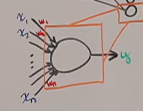

What happen here is that the inputs will mult by the weights and summed up to give us $y$


$$
y = f(b + \sum_{i=1}^n w_ix_i)
$$


$f$: is the activation func and are **Regression** or **Classification**

$b$ (bias): make the $y$ non zero


**Regression** : $f(x)$ return $xw+b$

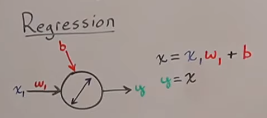


**Example:**

w = 3

b = -2


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style('darkgrid')
plt.style.use("dark_background")

In [60]:
w = 3
b = -2

def f(x):
    return w*x+b



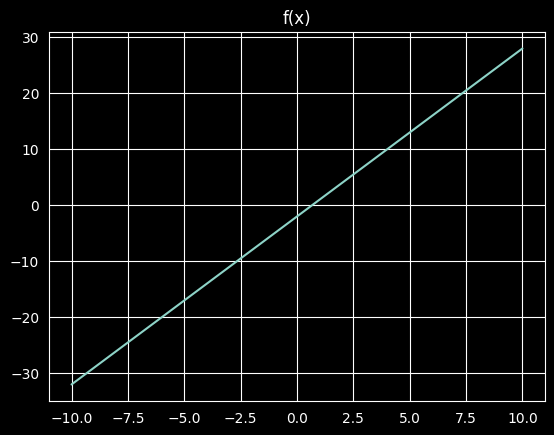

In [61]:
x = np.linspace(-10, 10, 100)


sns.lineplot(x=x, y=f(x))
plt.title("f(x)")
plt.show()

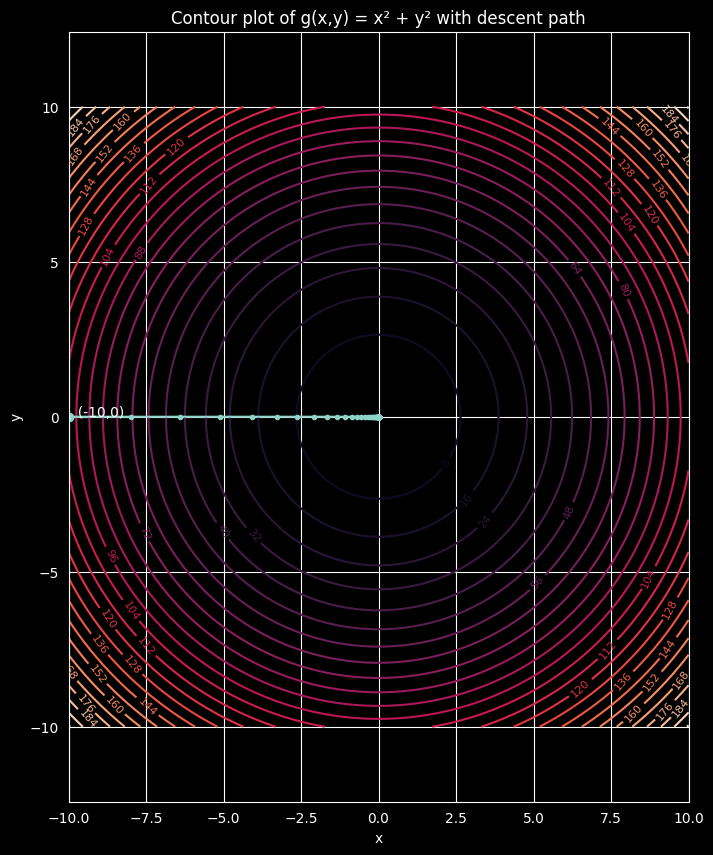

In [5]:
def g(x, y):
    return x**2 + y**2 +1


# Make grid data
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)
Z = g(X, Y)

plt.figure(figsize=(8, 10))

# Draw contour lines
contours = plt.contour(X, Y, Z, levels=30)
plt.clabel(contours, inline=True, fontsize=8)

# # ---- Plot special point (-5,5) ----
plt.scatter(-10, 0)
plt.text(-10, 0, "  (-10,0)", fontsize=10)

# # ---- Plot your iterative path ----
xp, yp = -10, 0
path_x = [xp]
path_y = [yp]

for i in range(1000000):
    xp = xp - 0.1*(2*xp)  # gradient step in x
    yp = yp - 0.1*(2*yp)  # gradient step in y
    path_x.append(xp)
    path_y.append(yp)

plt.plot(path_x, path_y, marker='o', markersize=3)

# Labels
plt.xlabel("x")
plt.ylabel("y")
plt.title("Contour plot of g(x,y) = x² + y² with descent path")

plt.axis('equal')
plt.show()


# Feed-Forward Neural Networks


> In neural network the input neurons is called **features**

> The output neurons is called **labels**

> The neurons between input and output layers are called **hidden layers**


# Neural Network from Scratch in Python


In [63]:
import numpy as np
from IPython.display import display, Math
def show_matrix(arr, name=""):
    """Display numpy array as LaTeX pmatrix using IPython display"""
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    
    rows = arr.shape[0]
    cols = arr.shape[1]
    
    matrix_str = r"\begin{pmatrix}" + "\n"
    for i in range(rows):
        row_str = " & ".join([f"{arr[i,j]:.1f}" for j in range(cols)])
        matrix_str += row_str
        if i < rows - 1:
            matrix_str += r" \\" + "\n"
    matrix_str += "\n" + r"\end{pmatrix}"
    
    if name:
        latex_str = f"{name} = {matrix_str}"
    else:
        latex_str = matrix_str
    
    return (latex_str)

In [64]:
# ----- Helper functions -----
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# ----- Dummy training data -----
# XOR-like problem
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([[0],[1],[1],[0]])

# ----- Initialize parameters -----
np.random.seed(42)

W1 = np.random.randn(2, 8) * 0.1
b1 = np.zeros((1, 8))

W2 = np.random.randn(8, 1) * 0.1
b2 = np.zeros((1, 1))

lr = 0.1

# ----- Training loop -----
for epoch in range(5000):

    z1 = X @ W1 + b1    
    a1 = relu(z1)
    
    z2 = a1 @ W2 + b2
    y_pred = sigmoid(z2)
    
    # Loss (Mean Squared Error)
    loss = np.mean((y - y_pred) ** 2)
    
    # find dl/w2
    dl_dy = 2 * (y_pred-y) / y.size
    dy_dz2 = y_pred * (1-y_pred)
    
    dz2 = dl_dy * dy_dz2

    
    dw2 =  a1.T @ dz2
    db2 = np.sum(dz2,axis=0,keepdims=True)    
    # find dl/dw1
    
    dl_da1 = dz2 @ W2.T
    da1_dz1 = relu_derivative(z1)
    dz1 = dl_da1 * da1_dz1


    
    dw1 = X.T @ dz1
    db1 = np.sum(dz1,axis=0,keepdims=True)

    W2 -= lr * dw2
    b2 -= lr * db2
    W1 -= lr * dw1
    b1 -= lr * db1

# ----- Test -----
print("Predictions after training:")
print(y_pred.round(3))


Predictions after training:
[[0.065]
 [0.974]
 [0.974]
 [0.018]]


## load digit dataset predicting hand written numbers


In [65]:
X.shape


(4, 2)

In [66]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def nn(X,y,W1,W2,b1,b2,lr):
    # ----- Training loop -----
    for epoch in range(2000):

        z1 = X @ W1 + b1    
        a1 = relu(z1)
        
        z2 = a1 @ W2 + b2
        y_pred = sigmoid(z2)
        
        # Loss (Mean Squared Error)
        # loss = np.mean((y - y_pred) ** 2)
        
        # find dl/w2
        dl_dy = 2 * (y_pred-y) / y.size
        dy_dz2 = y_pred * (1-y_pred)
        
        dz2 = dl_dy * dy_dz2

        
        dw2 =  a1.T @ dz2
        db2 = np.sum(dz2,axis=0,keepdims=True)    
        # find dl/dw1
        
        dl_da1 = dz2 @ W2.T
        da1_dz1 = relu_derivative(z1)
        dz1 = dl_da1 * da1_dz1


        
        dw1 = X.T @ dz1
        db1 = np.sum(dz1,axis=0,keepdims=True)

        W2 -= lr * dw2
        b2 -= lr * db2
        W1 -= lr * dw1
        b1 -= lr * db1
    return W1,W2,b1,b2


X,y  = load_digits(return_X_y=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

# One-hot encode labels
y_onehot = np.zeros((y.size, 10))
y_onehot[np.arange(y.size), y] = 1

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.33, random_state=42)
np.random.seed(42)

W1 = np.random.randn(64, 128) * 0.01
b1 = np.zeros((1, 128))

W2 = np.random.randn(128, 10) * 0.01
b2 = np.zeros((1, 10))

lr = 0.1



In [67]:
def predict(X):
    z1 = X @ W1 + b1    
    a1 = relu(z1)
    
    z2 = a1 @ W2 + b2
    y_pred = sigmoid(z2)
    return y_pred

In [68]:
def score(y_pred,y_test):
    pred_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_test, axis=1)

    accuracy = np.mean(pred_labels == true_labels)
    print("Test accuracy:", accuracy)

In [69]:
W1,W2,b1,b2 = nn(X_train,y_train,W1,W2,b1,b2,lr)

In [70]:
score(predict(X_test),y_test)

Test accuracy: 0.8148148148148148


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# -------------------
# Load Digits dataset
# -------------------
digits = load_digits()
X = digits.data      # shape: (1797, 64)   -> 8x8 images flattened
y = digits.target    # shape: (1797,)      -> labels 0–9

# Normalize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Convert to Torch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# -------------------
# Define Neural Network
# -------------------
class DigitNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)   # 10 digit classes
        )

    def forward(self, x):
        return self.net(x)

model = DigitNN()

# -------------------
# Loss and optimizer
# -------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [72]:
# -------------------
# Training loop
# -------------------
for epoch in range(100):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

# -------------------
# Testing
# -------------------
with torch.no_grad():
    test_outputs = model(X_test)
    predictions = torch.argmax(test_outputs, dim=1)
    accuracy = (predictions == y_test).float().mean()

print("\nTest Accuracy:", accuracy.item())

Epoch 10, Loss: 2.0281
Epoch 20, Loss: 1.5886
Epoch 30, Loss: 1.0601
Epoch 40, Loss: 0.6346
Epoch 50, Loss: 0.3915
Epoch 60, Loss: 0.2562
Epoch 70, Loss: 0.1754
Epoch 80, Loss: 0.1262
Epoch 90, Loss: 0.0951
Epoch 100, Loss: 0.0738

Test Accuracy: 0.9694444537162781


# Pytorch


In [73]:
import torch
import numpy as np

In [74]:
np.random.seed(42)

## Tensor and shapes


In [75]:
nparr = np.random.randn(2,3)
nparr

array([[ 0.49671415, -0.1382643 ,  0.64768854],
       [ 1.52302986, -0.23415337, -0.23413696]])

In [76]:
tensor = torch.randn(2,3)
tensor

tensor([[ 1.4113, -0.4270,  0.4352],
        [-1.2266, -0.0195, -0.7539]])

In [77]:
tensor.reshape(6,1)

tensor([[ 1.4113],
        [-0.4270],
        [ 0.4352],
        [-1.2266],
        [-0.0195],
        [-0.7539]])

## Math operations


In [78]:
tensor_a = (torch.randn(2,2) * 10).to(dtype=torch.int32)
tensor_b = (torch.randn(2,2) * 10).to(dtype=torch.int32)

In [81]:
display(Math(show_matrix(tensor_a) + "  " + show_matrix(tensor_b)))

<IPython.core.display.Math object>

In [86]:
# Add
torch.add(tensor_a,tensor_b) # or tensor_a+tensor_b

tensor([[ 5, 27],
        [ 6, -4]], dtype=torch.int32)

In [89]:
torch.sub(tensor_a,tensor_b) # or tensor_a-tensor_b

tensor([[ -9,   1],
        [ 18, -14]], dtype=torch.int32)

In [87]:
#Mul
# NxM * MxN => NxN
torch.mul(tensor_a,tensor_b) # or tensor_a*tensor_b

tensor([[-14, 182],
        [-72, -45]], dtype=torch.int32)

In [88]:
# Matrix multiplication
torch.matmul(tensor_a,tensor_b) # or tensor_a @ tensor_b


tensor([[-98,  44],
        [138, 111]], dtype=torch.int32)

In [90]:
# Reassignment

tensor_a = tensor_a + tensor_b # is equal to
tensor_a.add_(tensor_b)
tensor_a

tensor([[12, 40],
        [ 0,  1]], dtype=torch.int32)

## Neural Networks with Pytorch


In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [40]:
torch.manual_seed(42)

In [48]:
X,y = load_iris(return_X_y=True)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state=42)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [129]:

# create a model class that inherits nn.Module

class NN(nn.Module):
    # input
    def __init__(self,in_features,h1,h2,o_features):
        super().__init__()
        self.in_features = in_features
        self.h1 = h1
        self.h2 = h2
        self.o_features = o_features
        
        self.in_fc = nn.Linear(in_features,h1)
        self.fc1 = nn.Linear(h1,h2)
        self.out_fc = nn.Linear(h2,o_features)
    def forward(self,x):
        x = F.relu(self.in_fc(x))
        x = F.relu(self.fc1(x))
        x = self.out_fc(x)
        return x
    def predict(self,x):
        x = F.relu(self.in_fc(x))
        x = F.relu(self.fc1(x))
        x = self.out_fc(x)
        return x

In [143]:
model = NN(4,2,2,3)

In [145]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=.1)

In [146]:
epoch = 100

losses = []

In [ ]:
for i in range(epoch):

    y_pred = model.forward(X_train)
    
    loss = criterion(y_pred,y_train)
    
    losses.append(loss.detach().numpy())
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    if i%10 == 0:
        print(f'Epoch: {i} and loss: {loss}')
    

Epoch: 0 and loss: 1.1547447443008423
Epoch: 10 and loss: 1.095007061958313
Epoch: 20 and loss: 0.8681334853172302
Epoch: 30 and loss: 0.5598000288009644
Epoch: 40 and loss: 0.49273496866226196
Epoch: 50 and loss: 0.36107689142227173
Epoch: 60 and loss: 0.1874498426914215
Epoch: 70 and loss: 0.12773600220680237
Epoch: 80 and loss: 0.10164250433444977
Epoch: 90 and loss: 0.08789365738630295


<Axes: >

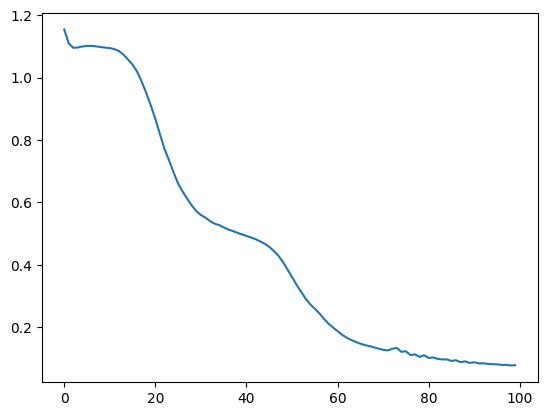

In [148]:
import seaborn as sns

# Convert numpy.ndarray elements in losses to Python floats
losses = [float(loss) for loss in losses]

sns.lineplot(x=range(epoch), y=losses)

In [149]:
# -------------------
# Testing
# -------------------
with torch.no_grad():
    test_outputs = model(X_test)
    predictions = torch.argmax(test_outputs, dim=1)
    accuracy = (predictions == y_test).float().mean()

print("\nTest Accuracy:", accuracy.item())


Test Accuracy: 1.0


### Save and Load Model


In [161]:
# Save the model

torch.save(model.state_dict(),'Iris flowers predictor.shk')

In [ ]:
# Load the model
# Load the model with correct dimensions
new_model = NN(4, 2, 2, 3)  # Use the same dimensions as the original model
new_model.load_state_dict(torch.load('Iris flowers predictor.shk'))

<All keys matched successfully>